In [94]:
import pandas as pd
import numpy as np
import pickle
import math
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import defaultdict


In [14]:
datasource_progression_graph = pd.read_parquet("datasource_harmonic.parquet")


In [15]:
datasource_progression_graph

,sourceId,targetId,source_type,target_type,relation,datasourceId,year,score,relation_key
0,CHEMBL1000,ENSG00000196639,molecule,target,modulated_by,chembl,2011.0,0.608273,chembl::modulated_by
1,CHEMBL1009,ENSG00000151577,molecule,target,modulated_by,chembl,2011.0,0.608273,chembl::modulated_by
2,CHEMBL1009,ENSG00000151577,molecule,target,modulated_by,chembl,2015.0,0.760341,chembl::modulated_by
3,CHEMBL1017,ENSG00000144891,molecule,target,modulated_by,chembl,2013.0,0.760341,chembl::modulated_by
4,CHEMBL103,ENSG00000082175,molecule,target,modulated_by,chembl,2017.0,0.760341,chembl::modulated_by
...,...,...,...,...,...,...,...,...,...
631510,Orphanet_2697,Orphanet_183539,disease,disease,is_subtype_of,disease_ontology,NaN,1.000000,disease_ontology::is_subtype_of
631511,Orphanet_2697,Orphanet_281241,disease,disease,is_subtype_of,disease_ontology,NaN,1.000000,disease_ontology::is_subtype_of
631512,Orphanet_2697,Orphanet_404577,disease,disease,is_subtype_of,disease_ontology,NaN,1.000000,disease_ontology::is_subtype_of
631513,Orphanet_357027,Orphanet_140162,disease,disease,is_subtype_of,disease_ontology,NaN,1.000000,disease_ontology::is_subtype_of


In [38]:
def build_graph_schema(df):
    """
    Build a schema of:
        - Node types
        - Relations
        - Node-pair → relations
        - Datasource → relation_key
        - Node-pair → relation_key
    PLUS:
        - Identify dynamic vs static edges
        - Datasource-level dynamic/static map
        - Relation-level dynamic/static map
        - Node-pair dynamic/static map
        - relation_key dynamic/static map
    """

    df = df.copy()

    # ------------------------------------------------------
    # 0. Identify dynamic vs static edges
    # ------------------------------------------------------
    df["edge_type"] = np.where(df["year"].isna(), "static", "dynamic")

    # If static-evidence loader already assigns a constant year like FIRST_YEAR-1:
    # Treat anything from STATIC_EDGE_DIR as static.
    if "relation_key" in df.columns:
        df.loc[df["relation_key"].str.contains("static", case=False, na=False), "edge_type"] = "static"

    # Datasource → static/dynamic
    datasource_type_map = (
        df.groupby("datasourceId")["edge_type"]
          .apply(lambda x: "dynamic" if (x == "dynamic").all()
                          else "static" if (x == "static").all()
                          else "mixed")
          .to_dict()
    )

    # Relation → static/dynamic/both
    relation_type_map = (
        df.groupby("relation")["edge_type"]
          .apply(lambda x: "dynamic" if (x == "dynamic").all()
                          else "static" if (x == "static").all()
                          else "mixed")
          .to_dict()
    )

    # relation_key → static/dynamic
    if "relation_key" in df.columns:
        relation_key_type_map = (
            df.groupby("relation_key")["edge_type"]
              .apply(lambda x: "dynamic" if (x == "dynamic").all()
                              else "static" if (x == "static").all()
                              else "mixed")
              .to_dict()
        )
    else:
        relation_key_type_map = {}

    # ------------------------------------------------------
    # 1. Node types
    # ------------------------------------------------------
    node_types = set(df["source_type"].unique()) | set(df["target_type"].unique())

    # ------------------------------------------------------
    # 2. Relations
    # ------------------------------------------------------
    edge_types = set(df["relation"].unique())

    # ------------------------------------------------------
    # 3. Node-pair → set of relations
    # ------------------------------------------------------
    merged_relation_pairs = {}

    for row in df.itertuples():
        s = row.source_type
        t = row.target_type
        r = row.relation

        key = tuple(sorted([s, t]))

        if key not in merged_relation_pairs:
            merged_relation_pairs[key] = set()

        merged_relation_pairs[key].add(r)

    relation_pairs = [(pair, sorted(list(rels))) for pair, rels in merged_relation_pairs.items()]

    # ------------------------------------------------------
    # 4. Datasource → relation_key
    # ------------------------------------------------------
    relation_key_map = (
        df.groupby("datasourceId")["relation_key"]
          .unique()
          .apply(lambda x: sorted(list(x)))
          .to_dict()
    )

    # ------------------------------------------------------
    # 5. Node-pair → datasource–relation
    # ------------------------------------------------------
    nodepair_to_relation_key = {}

    for row in df.itertuples():
        s = row.source_type
        t = row.target_type
        dr = row.relation_key

        key = tuple(sorted([s, t]))

        if key not in nodepair_to_relation_key:
            nodepair_to_relation_key[key] = set()

        nodepair_to_relation_key[key].add(dr)

    nodepair_to_relation_key = {
        k: sorted(list(v)) for k, v in nodepair_to_relation_key.items()
    }

    # ------------------------------------------------------
    # 6. Node-pair dynamic/static map
    # ------------------------------------------------------
    nodepair_type_map = {}

    for pair in merged_relation_pairs:
        # gather all rows that match this pair
        pair_mask = (
            (df["source_type"] == pair[0]) & (df["target_type"] == pair[1]) |
            (df["source_type"] == pair[1]) & (df["target_type"] == pair[0])
        )
        sub = df[pair_mask]["edge_type"]

        if (sub == "dynamic").all():
            t = "dynamic"
        elif (sub == "static").all():
            t = "static"
        else:
            t = "mixed"

        nodepair_type_map[pair] = t

    # ------------------------------------------------------
    # Print summary
    # ------------------------------------------------------
    print("\n=== GRAPH SCHEMA SUMMARY (dynamic + static annotated) ===\n")

    print("Node types:", node_types)
    print("Edge relation types:", edge_types)

    print("\nDatasource types (dynamic/static/mixed):")
    for ds, typ in datasource_type_map.items():
        print(f"  {ds}: {typ}")

    print("\nRelation types (dynamic/static/mixed):")
    for rel, typ in relation_type_map.items():
        print(f"  {rel}: {typ}")

    print("\nNode-pair types (dynamic/static/mixed):")
    for pair, typ in nodepair_type_map.items():
        print(f"  {pair}: {typ}")

    print("\nNode-pair → Relations:")
    for pair, rels in relation_pairs:
        print(f"  {pair}: {rels}")

    print("\nDatasource → relation_key:")
    for ds, drs in relation_key_map.items():
        print(f"  {ds}: {drs}")

    print("\nRelation_key types:")
    for rk, typ in relation_key_type_map.items():
        print(f"  {rk}: {typ}")

    print("\nNode-pair → datasource–relation keys:")
    for pair, drs in nodepair_to_relation_key.items():
        print(f"  {pair}: {drs}")

    print("\n=====================================================================\n")

    return {
        "node_types": node_types,
        "relation_pairs": relation_pairs,
        "relation_key_map": relation_key_map,
        "nodepair_to_relation_key": nodepair_to_relation_key,
        "datasource_type_map": datasource_type_map,
        "relation_type_map": relation_type_map,
        "relation_key_type_map": relation_key_type_map,
        "nodepair_type_map": nodepair_type_map,
    }
    
def build_schema_multigraph(schema):
    """
    Build a MultiGraph schema with:
        - Nodes = node types
        - Edges = datasource–relation pairs (relation_key)
        - Metadata:
              datasource
              relation
              relation_key
              type: dynamic/static/mixed (from schema)
    """

    G = nx.MultiGraph()

    # ------------------------------------------------------
    # 1. Add all node types
    # ------------------------------------------------------
    for n in schema["node_types"]:
        G.add_node(n)

    # ------------------------------------------------------
    # 2. Add edges based on nodepair_to_relation_key
    # ------------------------------------------------------
    relation_key_type = schema.get("relation_key_type_map", {})

    for (src, tgt), dr_list in schema["nodepair_to_relation_key"].items():

        for dr in dr_list:
            if "::" not in dr:
                print(f"⚠ Warning: malformed relation_key '{dr}'. Skipping.")
                continue

            datasource, relation = dr.split("::", 1)

            # determine whether dr is dynamic/static/mixed
            dr_type = relation_key_type.get(dr, "dynamic")  # default to dynamic

            G.add_edge(
                src, tgt,
                datasource=datasource,
                relation=relation,
                relation_key=dr,
                type=dr_type   # 🔥 added dynamic/static/mixed info
            )

    return G




In [ ]:
def build_relation_colors(G, cmap_name="tab20"):
    import matplotlib.cm as cm

    # Unique relations
    relations = sorted({d["relation"] for _, _, _, d in G.edges(keys=True, data=True)})

    cmap = cm.get_cmap(cmap_name, len(relations))
    rel_to_color = {rel: cmap(i) for i, rel in enumerate(relations)}

    # Provide relation → index to help edge ordering
    rel_to_index = {rel: idx for idx, rel in enumerate(relations)}

    return rel_to_color, rel_to_index

def refine_positions_with_repulsion(pos, G, steps=50, repulsion=0.05):
    """
    Apply a repulsion-only force pass to reduce edge overlaps.
    Works after spring_layout.

    repulsion: move nodes away from each other (higher = more spacing)
    """

    new_pos = pos.copy()

    nodes = list(G.nodes())

    for _ in range(steps):
        shift = {n: np.array([0.0, 0.0]) for n in nodes}

        for i, u in enumerate(nodes):
            for v in nodes[i+1:]:
                dx = new_pos[u][0] - new_pos[v][0]
                dy = new_pos[u][1] - new_pos[v][1]
                dist_sq = dx*dx + dy*dy + 1e-9

                # repulsive push
                force = repulsion / dist_sq
                fx = force * dx
                fy = force * dy

                shift[u] += np.array([fx, fy])
                shift[v] -= np.array([fx, fy])

        # update positions
        for n in nodes:
            new_pos[n] += shift[n]

    return new_pos



def plot_schema_graph_curved_legends_spaced(
    G,
    figsize=(14, 12),
    node_spacing_scale=2.0,
    base_rad=0.15
):
    """
    Plot schema graph with:
        - dynamic edges = solid
        - static edges = dotted/dashed
        - mixed edges = dashdot
        - non-overlapping spaced nodes
        - curved ordered coloured edges
        - legends for relations + datasource::relation keys
    """

    plt.figure(figsize=figsize)

    # ---------------------------------------------------------
    # 1. Compute spacious layout
    # ---------------------------------------------------------
    pos = nx.spring_layout(
        G,
        seed=42,
        k=node_spacing_scale,
        iterations=300
    )

    # push nodes apart further (repulsion)
    pos = refine_positions_with_repulsion(pos, G, steps=60, repulsion=0.02)

    # scale outward a little
    pos = {n: (x * 1.1, y * 1.1) for n, (x, y) in pos.items()}

    # ---------------------------------------------------------
    # 2. Colour by RELATION
    # ---------------------------------------------------------
    rel_to_color, rel_to_index = build_relation_colors(G)

    # group parallel edges (same node pair)
    parallel_edges = defaultdict(list)
    for (u, v, k, data) in G.edges(keys=True, data=True):
        pair = tuple(sorted([u, v]))
        parallel_edges[pair].append((u, v, k, data))

    # sort multi-edges inside each group by relation colour index
    for pair in parallel_edges:
        parallel_edges[pair].sort(key=lambda x: rel_to_index[x[3]["relation"]])

    # ---------------------------------------------------------
    # 3. Draw nodes
    # ---------------------------------------------------------
    nx.draw_networkx_nodes(G, pos, node_size=2400, node_color="#CFE3FF")
    nx.draw_networkx_labels(G, pos, font_size=13, font_weight="bold")

    # ---------------------------------------------------------
    # 4. Draw curved, coloured edges with dynamic/static styles
    # ---------------------------------------------------------
    # ---------------------------------------------------------
# 4. Draw curved, ordered, coloured edges (static dotted)
# ---------------------------------------------------------
    for pair, edges in parallel_edges.items():
        total = len(edges)

        for idx, (u, v, k, data) in enumerate(edges):

            rel = data["relation"]
            color = rel_to_color[rel]

            etype = data.get("type", "dynamic")

            # -------- Edge style --------
            if etype == "static":
                linestyle = "dotted"
                alpha = 1.0
            elif etype == "mixed":
                linestyle = "dashdot"
                alpha = 0.95
            else:
                linestyle = "solid"
                alpha = 0.9

            # -------- Curvature --------
            if total == 1:
                # Always give static edges a lift so they NEVER hide
                rad = 0.12 if etype == "static" else 0.0
            else:
                # Balanced curvature for multi-edges
                rad = base_rad * (idx - (total - 1) / 2)

                # Spread static edges further outward
                if etype == "static":
                    rad += 0.12
                elif etype == "mixed":
                    rad += 0.06

            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(u, v)],
                width=2.4,
                alpha=alpha,
                style=linestyle,
                connectionstyle=f"arc3,rad={rad}",
                edge_color=[color]
            )


    # ---------------------------------------------------------
    # 5. Legends
    # ---------------------------------------------------------

    # Legend 1: RELATIONS
    handles_rel = [
        plt.Line2D([0], [0], color=rel_to_color[rel], lw=4, label=rel)
        for rel in sorted(rel_to_color.keys())
    ]
    legend_rel = plt.legend(
        handles=handles_rel,
        title="Relation Types",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0)
    )
    plt.gca().add_artist(legend_rel)

    # Legend 2: DATASOURCE–RELATION KEYS
    ds_rel_unique = sorted({
        data["relation_key"]
        for _, _, _, data in G.edges(keys=True, data=True)
    })

    handles_dsrel = []
    for dr in ds_rel_unique:
        ds, rel = dr.split("::", 1)
        handles_dsrel.append(
            plt.Line2D([0], [0], color=rel_to_color[rel], lw=3, label=dr)
        )

    plt.legend(
        handles=handles_dsrel,
        title="Datasource::Relation",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.35)
    )

    # ---------------------------------------------------------
    # Final layout
    # ---------------------------------------------------------
    plt.title("Temporal Progression Graph Schema", fontsize=15)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [68]:
def plot_schema_graph_curved_legends_spaced(
    G,
    figsize=(14, 12),
    node_spacing_scale=2.0,
    base_rad=0.15
):
    """
    Plot schema graph with:
        - dynamic edges = solid
        - static edges = dotted, grey, thicker, separated curvature
        - mixed edges = dashdot
        - self-loops drawn explicitly as circular arcs
        - curved multi-edges for node pairs
        - node repulsion to reduce overlap
        - legends for relations + relation_keys
    """

    plt.figure(figsize=figsize)

    # ---------------------------------------------------------
    # 1. Compute spacious layout
    # ---------------------------------------------------------
    pos = nx.spring_layout(
        G,
        seed=42,
        k=node_spacing_scale,
        iterations=300
    )

    # Increase spacing (your refinement function)
    pos = refine_positions_with_repulsion(pos, G, steps=60, repulsion=0.02)

    # Expand outward slightly
    pos = {n: (x * 1.1, y * 1.1) for n, (x, y) in pos.items()}

    # ---------------------------------------------------------
    # 2. Colour mapping by relation
    # ---------------------------------------------------------
    rel_to_color, rel_to_index = build_relation_colors(G)

    # Group parallel edges (exclude loops in this stage)
    parallel_edges = defaultdict(list)
    for (u, v, k, data) in G.edges(keys=True, data=True):
        if u != v:
            pair = tuple(sorted([u, v]))
            parallel_edges[pair].append((u, v, k, data))

    # Sort non-loop multi-edges
    for pair in parallel_edges:
        parallel_edges[pair].sort(key=lambda x: rel_to_index[x[3]["relation"]])

    # ---------------------------------------------------------
    # 3. Draw nodes
    # ---------------------------------------------------------
    nx.draw_networkx_nodes(G, pos, node_size=2400, node_color="#CFE3FF")
    nx.draw_networkx_labels(G, pos, font_size=13, font_weight="bold")

    # ---------------------------------------------------------
    # 4. Separate edges by type
    # ---------------------------------------------------------
    loops = []
    dynamic_edges = []
    static_edges = []
    mixed_edges = []

    for (u, v, k, data) in G.edges(keys=True, data=True):
        etype = data.get("type", "dynamic")
        if u == v:
            loops.append((u, v, k, data))
        elif etype == "static":
            static_edges.append((u, v, k, data))
        elif etype == "mixed":
            mixed_edges.append((u, v, k, data))
        else:
            dynamic_edges.append((u, v, k, data))

    # ---------------------------------------------------------
    # DRAW DIRECTED SELF-LOOPS (Top → Left arc)
    # ---------------------------------------------------------
    from matplotlib.patches import FancyArrowPatch
    import numpy as np

    def draw_directed_loop_top_left(
        node, data, pos,
        node_radius=0.18,      # how far loop starts from node
        arc_height=0.75,       # vertical lift of loop
        arc_width=0.75,        # horizontal spread of loop
        arrow_size=22          # arrowhead size
    ):
        """
        Draw a directed self-loop that:
            - starts from TOP of the node
            - curves upward
            - ends on the LEFT side with arrowhead
        """

        x, y = pos[node]

        rel = data["relation"]
        etype = data.get("type", "dynamic")

        # Style based on static/dynamic/mixed
        if etype == "static":
            color = "#555555"
            style = "dotted"
            lw = 3.0
        elif etype == "mixed":
            color = rel_to_color[rel]
            style = "dashdot"
            lw = 2.8
        else:
            color = rel_to_color[rel]
            style = "solid"
            lw = 2.6

        # ---------------------------------------------
        # GEOMETRY:
        #   Start: top of node (x, y + R)
        #   Control: up & left
        #   End: left side of node
        # ---------------------------------------------
        start = (x, y + node_radius + 0.02)     # top of node
        end   = (x - node_radius - 0.05, y)     # left of node

        # Control points shape the arc:
        control1 = (x, y + arc_height)                       # directly above node
        control2 = (x - arc_width, y + arc_height * 0.6)     # upper-left curvature

        # Build a smooth cubic Bézier curve
        path_data = [
            ("M", start),
            ("C", control1),
            ("C", control2),
            ("L", end)
        ]

        # Convert into FancyArrowPatch
        arrow = FancyArrowPatch(
            start,
            end,
            connectionstyle=f"arc3,rad=0.52",
            arrowstyle="-|>",
            mutation_scale=arrow_size,
            lw=lw,
            linestyle=style,
            color=color,
            zorder=10
        )

        plt.gca().add_patch(arrow)


    # --- Draw all loops ---
    for (u, v, k, data) in loops:
        draw_directed_loop_top_left(u, data, pos)

    # ---------------------------------------------------------
    # 6. Helper: draw non-loop edges
    # ---------------------------------------------------------
    def draw_edge_group(edge_list, curvature_offset, linewidth, style, alpha, special_color=None):
        for (u, v, k, data) in edge_list:
            pair = tuple(sorted([u, v]))
            rel = data["relation"]

            # get color
            color = special_color if special_color else rel_to_color[rel]

            # find index of this edge in the multi-edge group
            edges_here = parallel_edges[pair]
            total = len(edges_here)
            idx = [i for i, e in enumerate(edges_here) if e[2] == k][0]

            # curvature
            if total == 1:
                rad = curvature_offset
            else:
                rad = (base_rad * (idx - (total - 1) / 2)) + curvature_offset

            nx.draw_networkx_edges(
                G, pos,
                edgelist=[(u, v)],
                width=linewidth,
                alpha=alpha,
                style=style,
                edge_color=[color],
                connectionstyle=f"arc3,rad={rad}"
            )

    # ---------------------------------------------------------
    # 7. DRAW NON-LOOP EDGES (static last)
    # ---------------------------------------------------------

    # Dynamic first
    draw_edge_group(dynamic_edges,
                    curvature_offset=0.00,
                    linewidth=2.4,
                    style="solid",
                    alpha=0.9)

    # Mixed next
    draw_edge_group(mixed_edges,
                    curvature_offset=0.08,
                    linewidth=2.8,
                    style="dashdot",
                    alpha=1.0)

    # Static last (grey, dotted, thick)
    draw_edge_group(static_edges,
                    curvature_offset=0.18,
                    linewidth=3.2,
                    style="dotted",
                    alpha=1.0,
                    special_color="#444444")

    # ---------------------------------------------------------
    # 8. LEGENDS
    # ---------------------------------------------------------

    # Legend 1: Relations
    handles_rel = [
        plt.Line2D([0], [0], color=rel_to_color[rel], lw=4, label=rel)
        for rel in sorted(rel_to_color.keys())
    ]
    legend_rel = plt.legend(
        handles=handles_rel,
        title="Relation Types",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0)
    )
    plt.gca().add_artist(legend_rel)

    # Legend 2: Datasource::Relation keys
    ds_rel_unique = sorted({
        data["relation_key"]
        for _, _, _, data in G.edges(keys=True, data=True)
    })

    handles_dsrel = [
        plt.Line2D([0], [0], color=rel_to_color[dr.split('::')[1]], lw=3, label=dr)
        for dr in ds_rel_unique
    ]

    plt.legend(
        handles=handles_dsrel,
        title="Datasource::Relation",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.35)
    )

    # ---------------------------------------------------------
    # Final layout
    # ---------------------------------------------------------
    plt.title("Temporal Progression Graph Schema", fontsize=15)
    plt.axis("off")
    plt.tight_layout()
    plt.show()



=== GRAPH SCHEMA SUMMARY (dynamic + static annotated) ===

Node types: {'go', 'disease', 'molecule', 'reactome', 'target'}
Edge relation types: {'associated_with', 'literature', 'affected_pathway', 'clinical_trial_Unknown/Operational', 'clinical_trial_adverse_effects', 'interacts_with', 'somatic_mutation', 'genetic_association', 'is_subpathway_of', 'clinical_trial_positive', 'is_subtype_of', 'clinical_trial_unmet_efficacy', 'gene_ontology_annotation', 'involved_in', 'modulated_by', 'animal_model', 'rna_expression'}

Datasource types (dynamic/static/mixed):
  cancer_biomarkers: dynamic
  cancer_gene_census: dynamic
  chembl: dynamic
  clingen: dynamic
  crispr: dynamic
  crispr_screen: dynamic
  disease_ontology: static
  europepmc: dynamic
  eva: dynamic
  eva_somatic: dynamic
  expression_atlas: dynamic
  gene2phenotype: dynamic
  gene_burden: dynamic
  gene_ontology: static
  genomics_england: dynamic
  impc: dynamic
  orphanet: dynamic
  protein_protein_interaction: static
  reacto

/var/folders/k1/hcghm9xd1_qcbkz71tsp36fc0000gp/T/ipykernel_97795/1085095854.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name, len(relations))


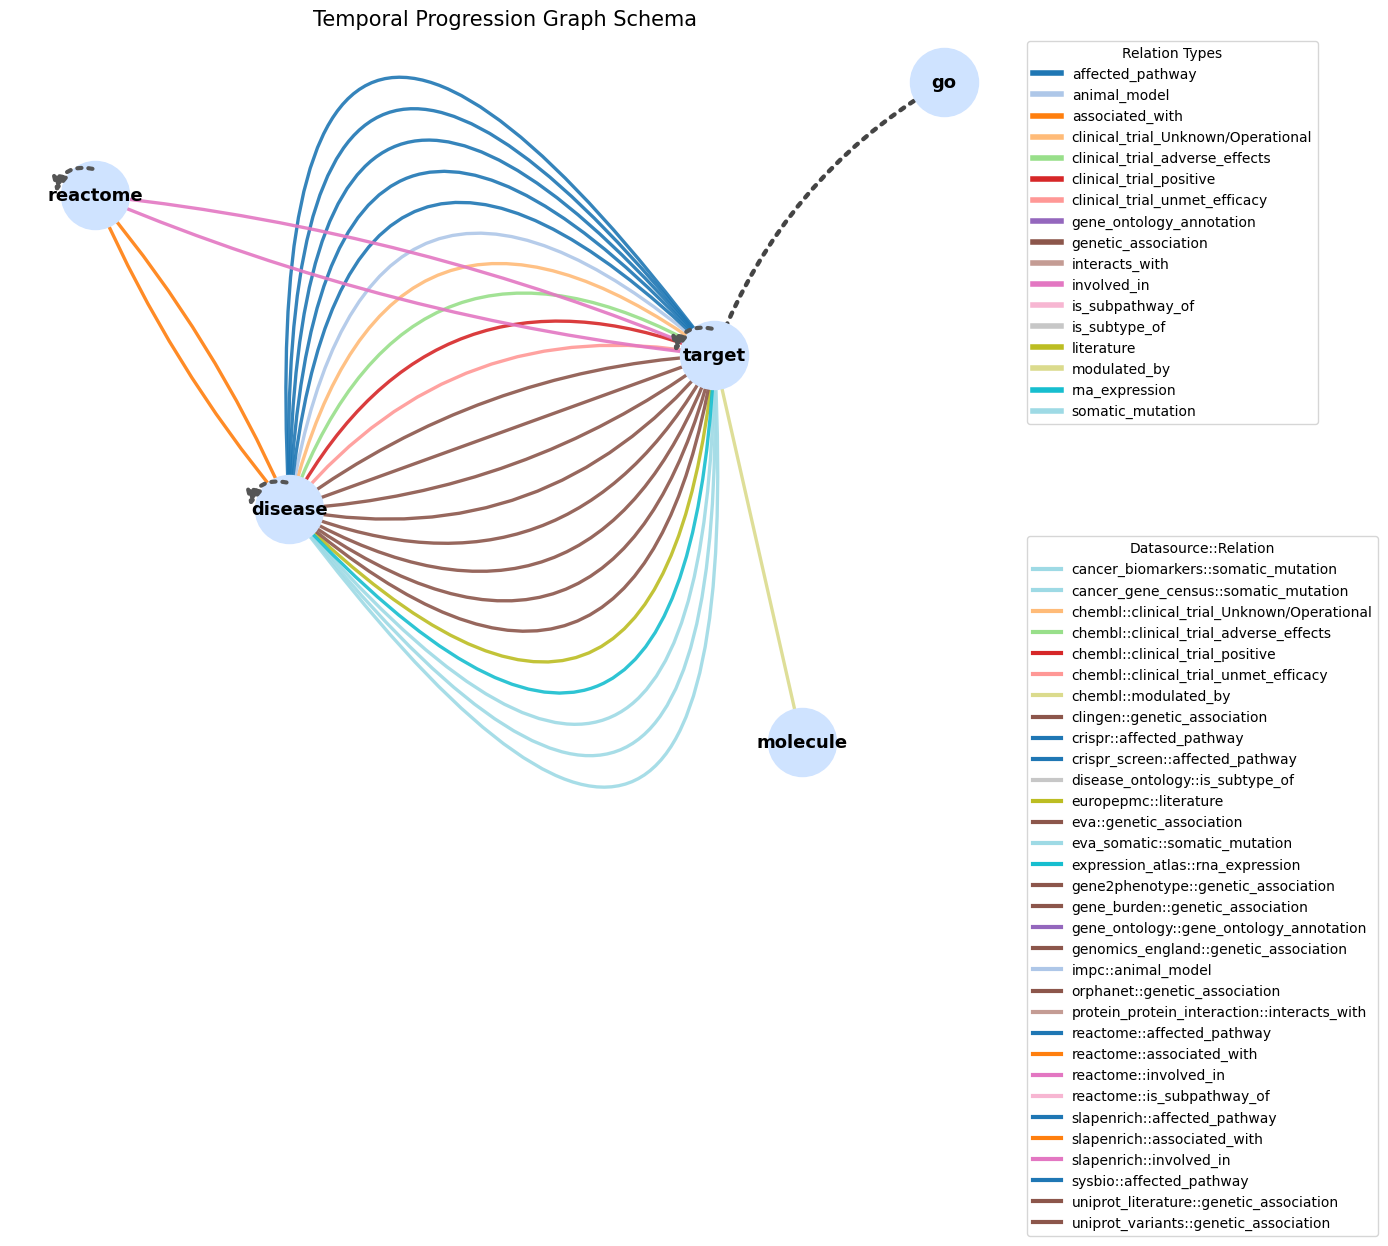

In [69]:
schema = build_graph_schema(datasource_progression_graph)
G = build_schema_multigraph(schema)
plot_schema_graph_curved_legends_spaced(G)

In [70]:
def count_edges_by_relation_and_datasource(df: pd.DataFrame) -> pd.DataFrame:
    """
    Produce a table counting number of edges grouped by:
        relation × datasourceId
    """
    table = (
        df.groupby(["source_type", "target_type", "relation", "datasourceId"])
          .size()
          .reset_index(name="edge_count")
          .sort_values(["relation", "datasourceId"])
    )
    return table

edge_table = count_edges_by_relation_and_datasource(datasource_progression_graph)

print(edge_table)



   source_type target_type                            relation  \
9       target     disease                    affected_pathway   
10      target     disease                    affected_pathway   
11      target     disease                    affected_pathway   
12      target     disease                    affected_pathway   
13      target     disease                    affected_pathway   
14      target     disease                        animal_model   
1      disease    reactome                     associated_with   
2      disease    reactome                     associated_with   
3      disease      target  clinical_trial_Unknown/Operational   
4      disease      target      clinical_trial_adverse_effects   
5      disease      target             clinical_trial_positive   
6      disease      target       clinical_trial_unmet_efficacy   
28      target          go            gene_ontology_annotation   
15      target     disease                 genetic_association   
16      ta

In [81]:
datasource_progression_graph = datasource_progression_graph[~datasource_progression_graph['year'].isna()]

In [95]:
import hashlib
import colorsys

GLASBEY_32 = [
    "#000000", "#ff0000", "#00ff00", "#0000ff", "#ffff00", "#00ffff", "#ff00ff",
    "#800000", "#008000", "#000080", "#808000", "#008080", "#800080",
    "#ff8080", "#80ff80", "#8080ff", "#ffff80", "#80ffff", "#ff80ff",
    "#ff8000", "#80ff00", "#00ff80", "#0080ff", "#8000ff",
    "#ff0080", "#00ff80", "#0080ff",
    "#c0c0c0", "#808080", "#404040", "#202020", "#e0e0e0"
]


def generate_edge_color_map(edge_types):
    """
    Assign each edge (relation) type a unique Glasbey colour.
    Works up to 32 relation types.
    """
    edge_types = sorted(edge_types)   # ensure deterministic order

    if len(edge_types) > len(GLASBEY_32):
        raise ValueError(
            f"Too many edge types ({len(edge_types)}). "
            f"Glasbey_32 supports max {len(GLASBEY_32)}."
        )

    return {
        et: GLASBEY_32[i]
        for i, et in enumerate(edge_types)
    }

def generate_node_color_map(node_types):
    """
    Assign each node type a Glasbey colour (first N entries).
    """
    node_types = sorted(node_types)

    if len(node_types) > len(GLASBEY_32):
        raise ValueError(
            f"Too many node types ({len(node_types)}). "
            f"Glasbey_32 supports max {len(GLASBEY_32)}."
        )

    return {
        nt: GLASBEY_32[i]
        for i, nt in enumerate(node_types)
    }



edge_types = datasource_progression_graph["relation_key"].unique()
edge_colors = generate_edge_color_map(edge_types)

node_types = set(datasource_progression_graph["source_type"]) | set(datasource_progression_graph["target_type"])
node_colors = generate_node_color_map(node_types)

In [102]:
def node_type_per_year(df):
    """
    Calculate the count of each node type per year in the given dataframe.
    """
    if "source_type" not in df.columns or "target_type" not in df.columns:
        return {}

    result = {}

    for y, sub in df.groupby("year"):
        nodes = pd.concat([
            sub[["sourceId", "source_type"]].rename(columns={"sourceId": "node", "source_type": "type"}),
            sub[["targetId", "target_type"]].rename(columns={"targetId": "node", "target_type": "type"})
        ]).drop_duplicates()

        result[y] = nodes["type"].value_counts().to_dict()

    return result

def edge_type_per_year(df):
    return {
        y: sub["relation_key"].value_counts().to_dict()
        for y, sub in df.groupby("year")
    }

def compute_drec(df):
    df = df.sort_values("year")
    years = sorted(df.year.unique())

    numer = 0
    denom = 0

    for i in range(len(years)-1):
        y = years[i]
        yn = years[i+1]

        E_t = set(map(tuple, df[df.year == y][["sourceId","targetId","relation_key"]].values))
        E_next = set(map(tuple, df[df.year == yn][["sourceId","targetId","relation_key"]].values))

        numer += len(E_t & E_next)
        denom += len(E_t)

    return numer / denom if denom else 0

def compute_rec(df):
    df = df.sort_values("year")
    seen = {}
    
    for y, sub in df.groupby("year"):
        edges = set(map(tuple, sub[["sourceId", "targetId", "relation_key"]].values))
        for e in edges:
            if e in seen:
                seen[e] = True
            else:
                seen[e] = False

    # proportion that repeated at least once
    return sum(seen.values()) / len(seen) if len(seen) else 0

from collections import defaultdict

def compute_consecutiveness(df):
    df = df.sort_values("year")
    years_by_edge = defaultdict(list)

    for _, row in df.iterrows():
        e = (row.sourceId, row.targetId, row.relation_key)
        years_by_edge[e].append(row.year)

    def max_run(years):
        years = sorted(years)
        longest = 1
        streak = 1
        for i in range(1, len(years)):
            if years[i] == years[i-1] + 1:
                streak += 1
                longest = max(longest, streak)
            else:
                streak = 1
        return longest

    runs = [max_run(yrs) for yrs in years_by_edge.values()]
    return sum(runs) / len(runs) if runs else 0

def compute_cumulative_evidence_diversity_per_year(df):
    """
    Computes cumulative evidence diversity (evidence maturation)
    for target-disease pairs across years.

    For each year y:
        diversity_y = avg number of distinct evidence types
                      ever observed for each TD pair up to year y
    """

    df = df.sort_values("year")

    # keep only target-disease edges (both directions allowed)
    td = df[
        ((df["source_type"] == "target") & (df["target_type"] == "disease")) |
        ((df["source_type"] == "disease") & (df["target_type"] == "target"))
    ]

    cumulative_support = {}      # {(sourceId, targetId): set(relation_types)}
    results = {}                 # {year: diversity_value}

    for y, sub in td.groupby("year"):
        # update cumulative evidence
        for _, row in sub.iterrows():
            pair = (row.sourceId, row.targetId)
            if pair not in cumulative_support:
                cumulative_support[pair] = set()
            cumulative_support[pair].add(row.relation_key)

        # compute cumulative diversity for this year
        if len(cumulative_support) > 0:
            diversities = [len(s) for s in cumulative_support.values()]
            results[y] = sum(diversities) / len(diversities)
        else:
            results[y] = 0.0

    return results

def compute_evidence_proportion_per_year(df):
    """
    Compute percentage proportion of each evidence type (relation_key)
    for every year in the dataset.

    Returns:
        pandas.DataFrame indexed by year
        columns = relation types
        values = proportion (0–1)
    """

    # count edges by (year, relation)
    prop = (
        df.groupby(["year", "relation_key"])
          .size()
          .reset_index(name="count")
    )

    # pivot → rows = years, cols = relation types
    pivot = prop.pivot(
        index="year",
        columns="relation_key",
        values="count"
    ).fillna(0)

    # normalise row-wise → percentage distribution
    pivot = pivot.div(pivot.sum(axis=1), axis=0)

    return pivot

def compute_evidence_counts_per_year(df):
    """
    Compute ABSOLUTE number of edges per evidence type (relation_key)
    for each year.

    Returns:
        pandas.DataFrame indexed by year,
        columns = relation types,
        values = absolute counts (int)
    """

    # count edges by (year, relation)
    counts = (
        df.groupby(["year", "relation_key"])
          .size()
          .reset_index(name="count")
    )

    # pivot → rows = years, cols = relation types
    pivot = counts.pivot(
        index="year",
        columns="relation_key",
        values="count"
    ).fillna(0)

    return pivot

def compute_harmonic_sum_distribution(df):
    """
    Build a nested dictionary:
        { relation : { relation_key : list_of_scores } }
    """
    df = df.copy()

    if "relation" not in df or "relation_key" not in df or "score" not in df:
        raise ValueError("df must contain 'relation', 'relation_key', and 'score' columns.")

    nested = {}

    grouped = df.groupby(["relation", "relation_key"])["score"]

    for (rel, rkey), scores in grouped:
        if rel not in nested:
            nested[rel] = {}
        nested[rel][rkey] = list(scores)

    return nested





In [97]:
def compute_dataset_stats(df):
    stats = {}

    # Basic dataset-level stats
    stats["# Quadruples"] = len(df)
    stats["# Nodes"] = len(set(df["sourceId"]).union(set(df["targetId"])))
    stats["# Edge Types"] = df["relation_key"].nunique()
    stats["# Node Types"] = len(set(df["source_type"]).union(df["target_type"]))
    stats["# Timesteps"] = df["year"].nunique()
    stats["Granularity"] = "year"

    # mean edges per year
    edges_per_year = df.groupby("year").size()
    stats["Mean Edges/Ts."] = edges_per_year.mean()

    # mean nodes per year
    nodes_per_year = (
        df.groupby("year")[["sourceId", "targetId"]]
          .agg(lambda s: len(set(s)))
          .sum(axis=1)
    )
    stats["Mean Nodes/Ts."] = nodes_per_year.mean()

    # ------ Module 3 metrics ------
    # FIX: removed trailing commas (those created tuples)
    stats["Direct Recurrency (DRec)"] = compute_drec(df)
    stats["Recurrency (Rec)"] = compute_rec(df)
    stats["Consecutiveness (Con)"] = compute_consecutiveness(df)

    return stats

def compute_plot_stats(df, split_year=None):
    df = df.sort_values("year")

    if split_year is None:
        split_year = int(np.median(df.year.unique()))

    stats = {
        "node_type_per_year": node_type_per_year(df),
        "edge_type_per_year": edge_type_per_year(df),
        "cumulative_evidence_diversity": compute_cumulative_evidence_diversity_per_year(df),
        "harmonic_sum_distribution": compute_harmonic_sum_distribution(df),
        "evidence_proportion_per_year": compute_evidence_proportion_per_year(df),
        "evidence_count_per_year": compute_evidence_counts_per_year(df)
    }

    return stats



In [107]:
def plot_edge_type_per_year(edge_type_dict, edge_color_map):
    plt.figure(figsize=(14,7))

    years = sorted(edge_type_dict.keys())
    all_rels = sorted({r for ydata in edge_type_dict.values() for r in ydata})

    for r_name in all_rels:
        vals = [edge_type_dict[y].get(r_name, 0) for y in years]
        color = edge_color_map.get(r_name, "#999999")  # fallback grey
        plt.plot(years, vals, marker='o', label=r_name, color=color)

    plt.title("Edge Types Per Year")
    plt.xlabel("Year")
    plt.ylabel("Edge Count")
    plt.xticks(rotation=45)

    # Legend scroll for many relations
    plt.legend(
        title="Relation Type",
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    plt.tight_layout()
    plt.show()
    
def plot_node_type_per_year(node_type_dict, node_color_map):
    plt.figure(figsize=(12,6))

    years = sorted(node_type_dict.keys())
    all_types = sorted({t for d in node_type_dict.values() for t in d})

    for t_name in all_types:
        vals = [node_type_dict[y].get(t_name, 0) for y in years]
        color = node_color_map.get(t_name, "#999999")
        plt.plot(years, vals, marker='o', label=t_name, color=color)

    plt.title("Node Types Per Year")
    plt.xlabel("Year")
    plt.ylabel("Node Count")
    plt.xticks(rotation=45)
    plt.legend(title="Node Type")
    plt.tight_layout()
    plt.show()

def plot_cumulative_evidence_diversity(stats):
    years = sorted(stats.keys())
    vals = [stats[y] for y in years]

    plt.figure(figsize=(10,5))
    plt.plot(years, vals, marker="o")
    plt.title("Cumulative Evidence Diversity (Evidence Maturation)")
    plt.xlabel("Year")
    plt.ylabel("Distinct Evidence Types (Cumulative)")
    plt.tight_layout()
    plt.show()
    

def plot_score_percentage(nested_dist, edge_color_map, bins=40):
    """
    For each RELATION create a subplot.
    Inside each subplot, plot score distributions for each relation_key.
    """

    relations = sorted(nested_dist.keys())
    n = len(relations)

    cols = min(3, n)
    rows = math.ceil(n / cols)

    # Increase width to make space for legends
    fig, axs = plt.subplots(rows, cols, figsize=(6.5*cols, 4.2*rows), squeeze=False)
    axs = axs.flatten()

    for i, rel in enumerate(relations):
        ax = axs[i]
        rkeys = nested_dist[rel]

        # Different colors for each relation_key
        cmap = plt.cm.get_cmap("tab20", len(rkeys))

        for j, (rkey, scores) in enumerate(rkeys.items()):
            scores = np.array(scores)

            counts, bin_edges = np.histogram(scores, bins=bins, range=(0, 1))
            pct = counts / counts.sum() * 100
            centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

            ax.plot(
                centers, pct,
                color=cmap(j),
                linewidth=2,
                label=rkey
            )

        ax.set_title(rel, fontsize=13)
        ax.set_xlim(0, 1)
        ax.set_xlabel("Harmonic score")
        ax.set_ylabel("Percentage (%)")
        ax.grid(alpha=0.25)

        # -------------------------
        # Legend OUTSIDE subplot
        # -------------------------
        ax.legend(
            fontsize=8,
            loc="upper left",
            bbox_to_anchor=(1.02, 1),
            borderaxespad=0,
            frameon=False
        )

    # Hide any empty axes
    for j in range(i+1, len(axs)):
        axs[j].axis("off")

    plt.tight_layout()
    plt.show()



def plot_evidence_proportion_per_year(pivot_df, edge_color_map):
    modalities = pivot_df.columns.tolist()
    colors = [edge_color_map.get(m, "#999999") for m in modalities]

    pivot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(15, 7),
        color=colors,
        width=0.9
    )

    plt.title("Proportion of Evidence Types per Year")
    plt.xlabel("Year")
    plt.ylabel("Proportion")
    plt.legend(title="Relation Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

def plot_evidence_counts_per_year(pivot_df, edge_color_map):
    """
    Stacked bar plot of absolute number of edges per year,
    one bar per year, stacked by evidence type.
    """

    modalities = pivot_df.columns.tolist()
    colors = [edge_color_map.get(m, "#999999") for m in modalities]

    pivot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(15, 7),
        color=colors,
        width=0.9
    )

    plt.title("Absolute Number of Evidence Edges per Year")
    plt.xlabel("Year")
    plt.ylabel("Number of Edges")
    plt.legend(title="Relation Type", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


In [104]:
dataset_stats = compute_dataset_stats(datasource_progression_graph)
pd.DataFrame(dataset_stats.items(), columns=["Statistic", "Value"])


,Statistic,Value
0,# Quadruples,60372
1,# Nodes,16392
2,# Edge Types,28
3,# Node Types,4
4,# Timesteps,15
5,Granularity,year
6,Mean Edges/Ts.,4024.8
7,Mean Nodes/Ts.,3544.533333
8,Direct Recurrency (DRec),0.142886
9,Recurrency (Rec),0.173384


In [105]:
plot_stats = compute_plot_stats(datasource_progression_graph)


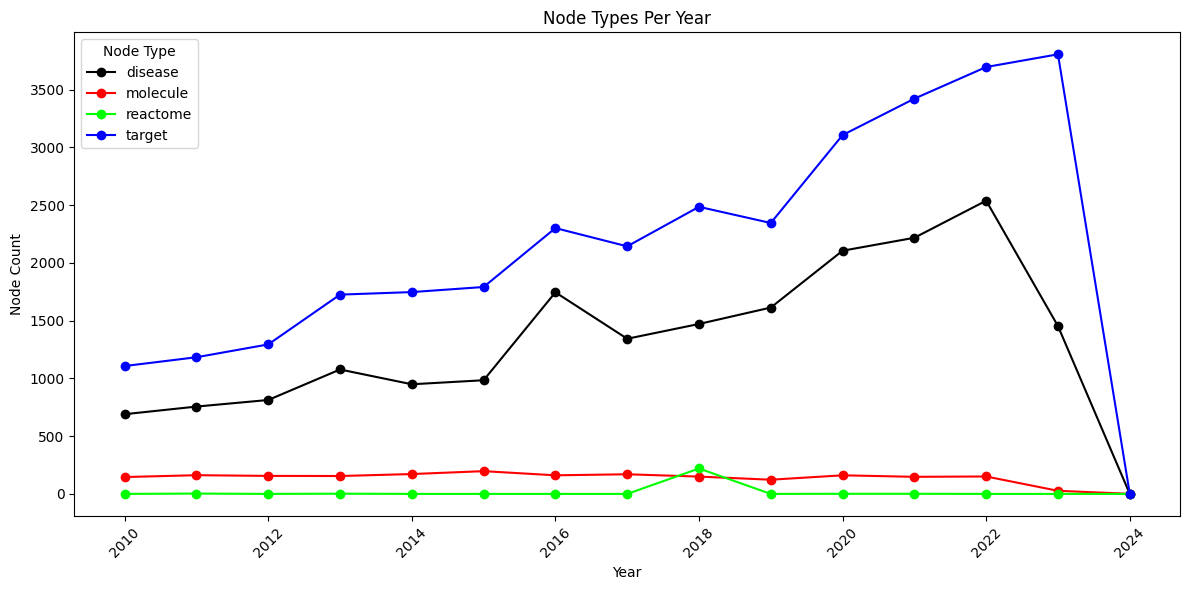

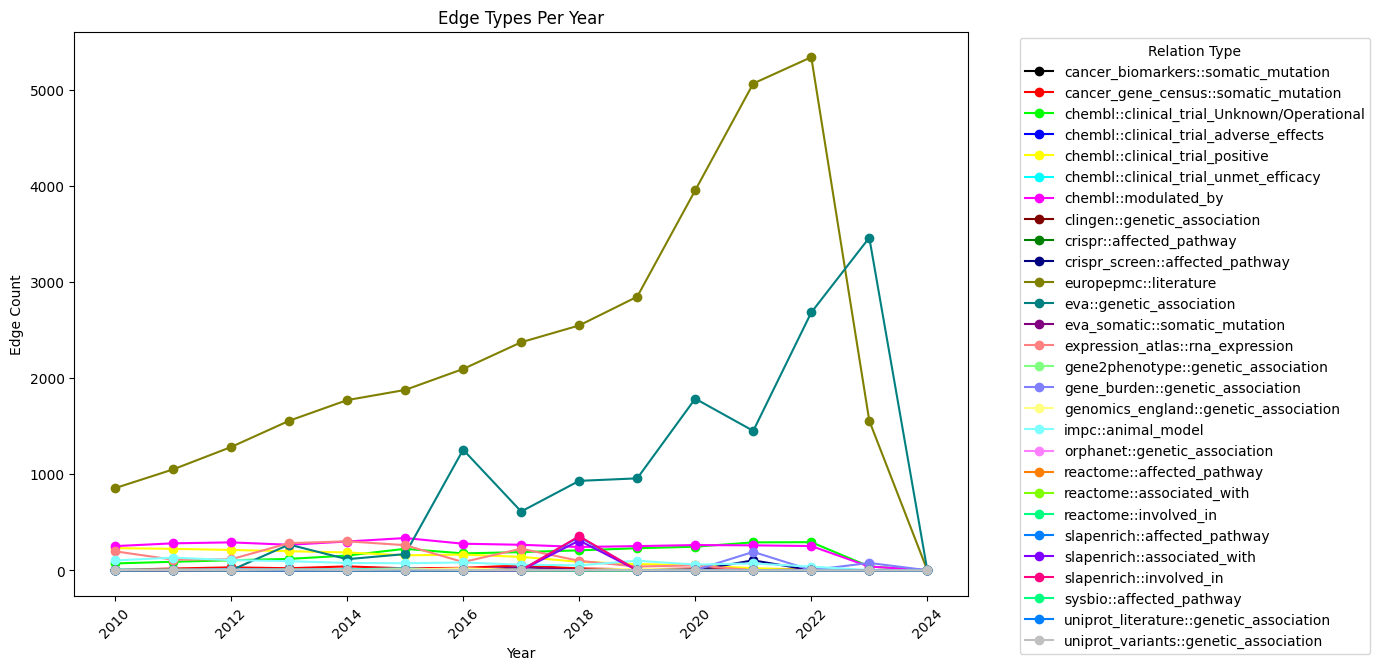

/var/folders/k1/hcghm9xd1_qcbkz71tsp36fc0000gp/T/ipykernel_97795/615280236.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(rkeys))


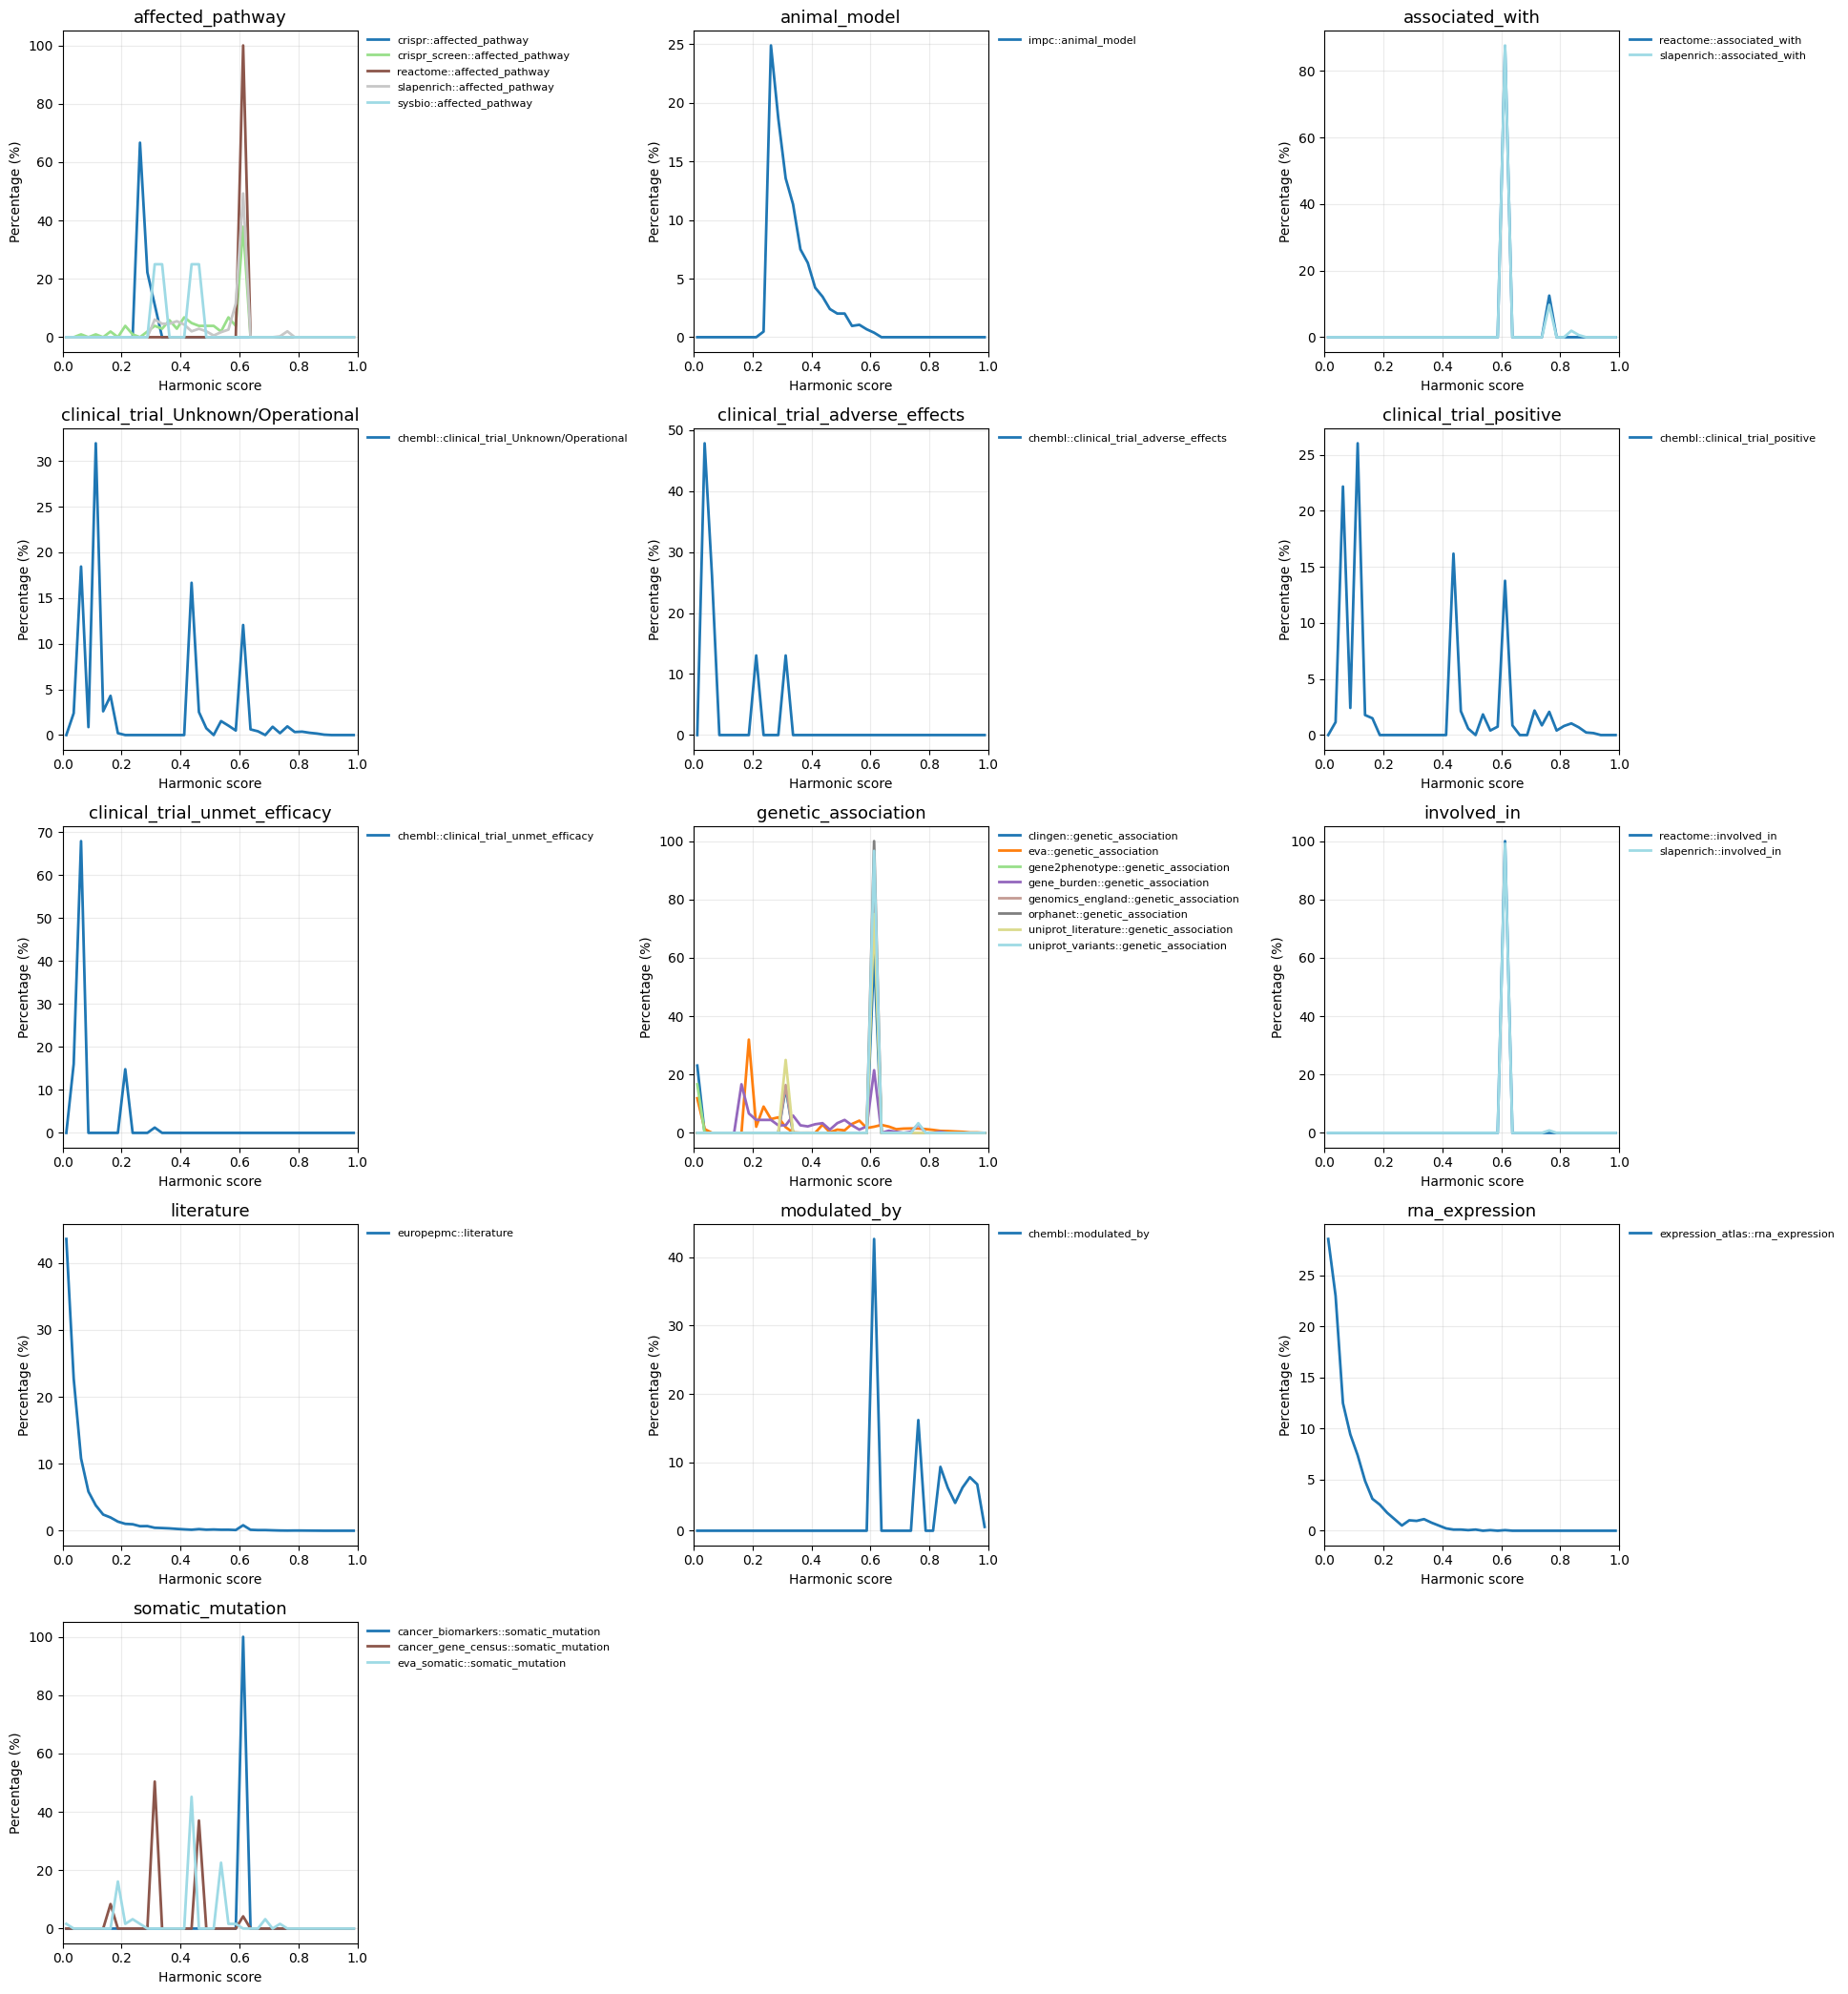

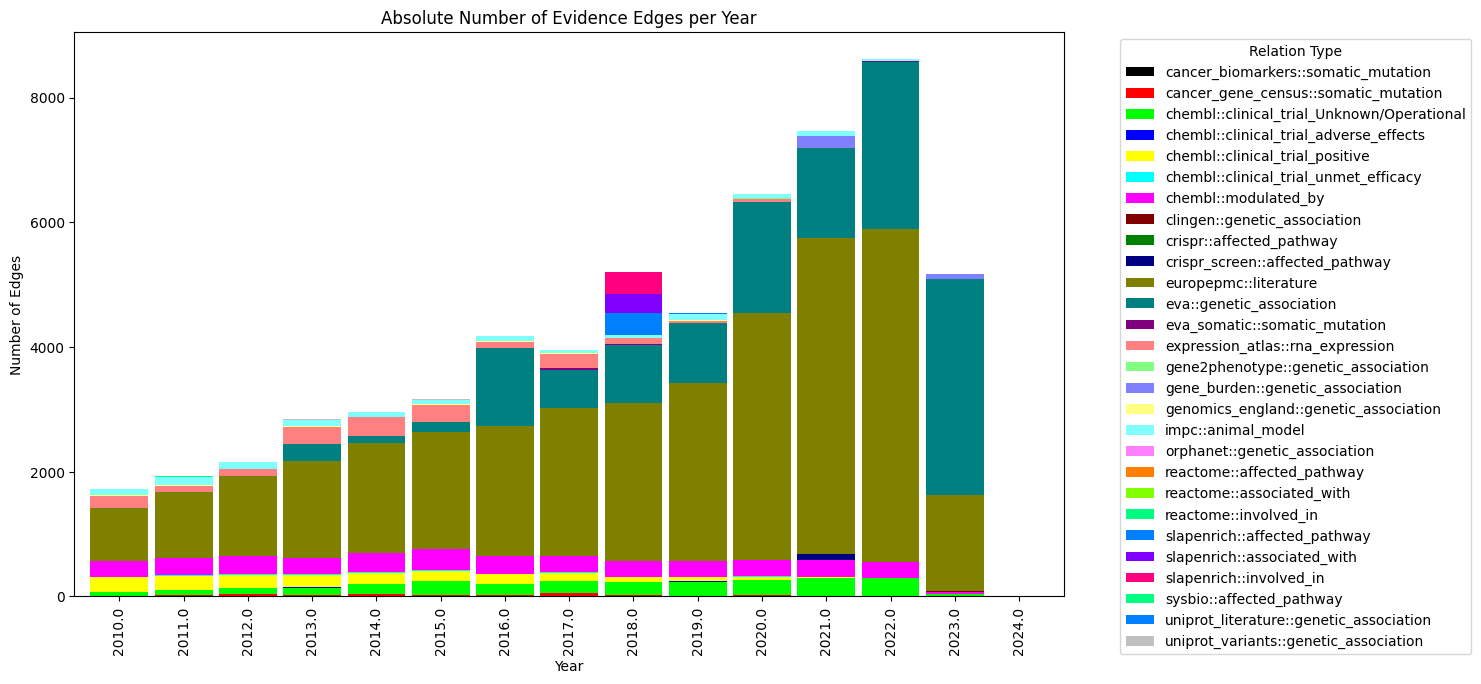

In [108]:
plot_node_type_per_year(plot_stats["node_type_per_year"], node_colors)
plot_edge_type_per_year(plot_stats["edge_type_per_year"], edge_colors)
plot_score_percentage(plot_stats["harmonic_sum_distribution"], edge_colors)
plot_evidence_counts_per_year(plot_stats['evidence_count_per_year'], edge_color_map=edge_colors)
